# 4. Analise de cluster -- Soja no Parana

Mesma logica do pipeline de milho (`4. Cluster Analysis.ipynb`): agrupa os municipios por
similaridade climatica (clustering hierarquico, linkage Ward) para depois calibrar o
WOFOST separadamente por cluster. A diferenca e que aqui os arquivos `point_id_*.nc` ja
usam o esquema de variaveis do WOFOST (`IRRAD, TMIN, TMAX, RAIN, WIND, T2M`) em vez dos
nomes brutos da NASA POWER.

Como o pipeline de milho nao mostrava explicitamente onde o `cluster_id` era gravado de
volta nos arquivos `point_id_*.nc` (so salvava um CSV `resultados_cluster.csv`), esta
etapa foi completada aqui: depois de calcular os clusters, o `cluster_id` de cada
municipio e **gravado como atributo global** no respectivo `point_id_<cod>.nc`, que e
exatamente o que `NetCDFDataLoader.get_point_info` (`util/SensitivityAnalyzer.py`) espera
ler (`ds.attrs.get('cluster_id', None)`).


In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd(), 'util'))
from util.utils_soja_pr import setup_paths_soja_pr

paths = setup_paths_soja_pr()

N_CLUSTERS = 4  # PR e um unico estado: menos heterogeneidade climatica que o dataset
                # global de milho (que usava 5) -- ajuste conforme a analise do dendrograma.

arquivos_nc = glob.glob(os.path.join(paths['COMPLETO'], "point_id_*.nc"))
print(f"Total de arquivos: {len(arquivos_nc)}")


Total de arquivos: 392


In [2]:
variaveis_clima = ['IRRAD', 'TMIN', 'TMAX', 'RAIN', 'WIND', 'T2M']

dados_agregados = []
for arquivo in tqdm(arquivos_nc, desc="Processando arquivos"):
    ponto_id = os.path.basename(arquivo).replace('point_id_', '').replace('.nc', '')
    try:
        with xr.open_dataset(arquivo) as ds:
            estatisticas = {'ID': ponto_id}
            for var in variaveis_clima:
                if var in ds.data_vars:
                    estatisticas[f'{var}_mean'] = float(ds[var].mean(skipna=True).values)
                    estatisticas[f'{var}_std'] = float(ds[var].std(skipna=True).values)
                    estatisticas[f'{var}_median'] = float(ds[var].median(skipna=True).values)
                    estatisticas[f'{var}_min'] = float(ds[var].min(skipna=True).values)
                    estatisticas[f'{var}_max'] = float(ds[var].max(skipna=True).values)
            dados_agregados.append(estatisticas)
    except Exception as e:
        print(f"Erro ao processar {ponto_id}: {e}")

df_cluster = pd.DataFrame(dados_agregados).set_index('ID')
df_cluster_clean = df_cluster.dropna()
print(f"Dados agregados: {df_cluster.shape} | apos remover NaN: {df_cluster_clean.shape}")


Processando arquivos: 100%|██████████| 392/392 [08:40<00:00,  1.33s/it]

Dados agregados: (392, 30) | apos remover NaN: (392, 30)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_clean)

linkage_matrix = linkage(X_scaled, method='ward')

model = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric="euclidean", linkage="ward")
clusters = model.fit_predict(X_scaled)

df_cluster_clean['Cluster'] = clusters

resultado_path = os.path.join(paths['COMPLETO'], 'resultados_cluster_pr.csv')
df_cluster_clean.to_csv(resultado_path)

print("Distribuicao dos clusters:")
print(df_cluster_clean['Cluster'].value_counts().sort_index())
print(f"\nResultados salvos em: {resultado_path}")


Distribuicao dos clusters:
Cluster
0    191
1     57
2     71
3     73
Name: count, dtype: int64

Resultados salvos em: d:\_py\AgroIA_prod\inputs\data\soja_pr\completo\resultados_cluster_pr.csv


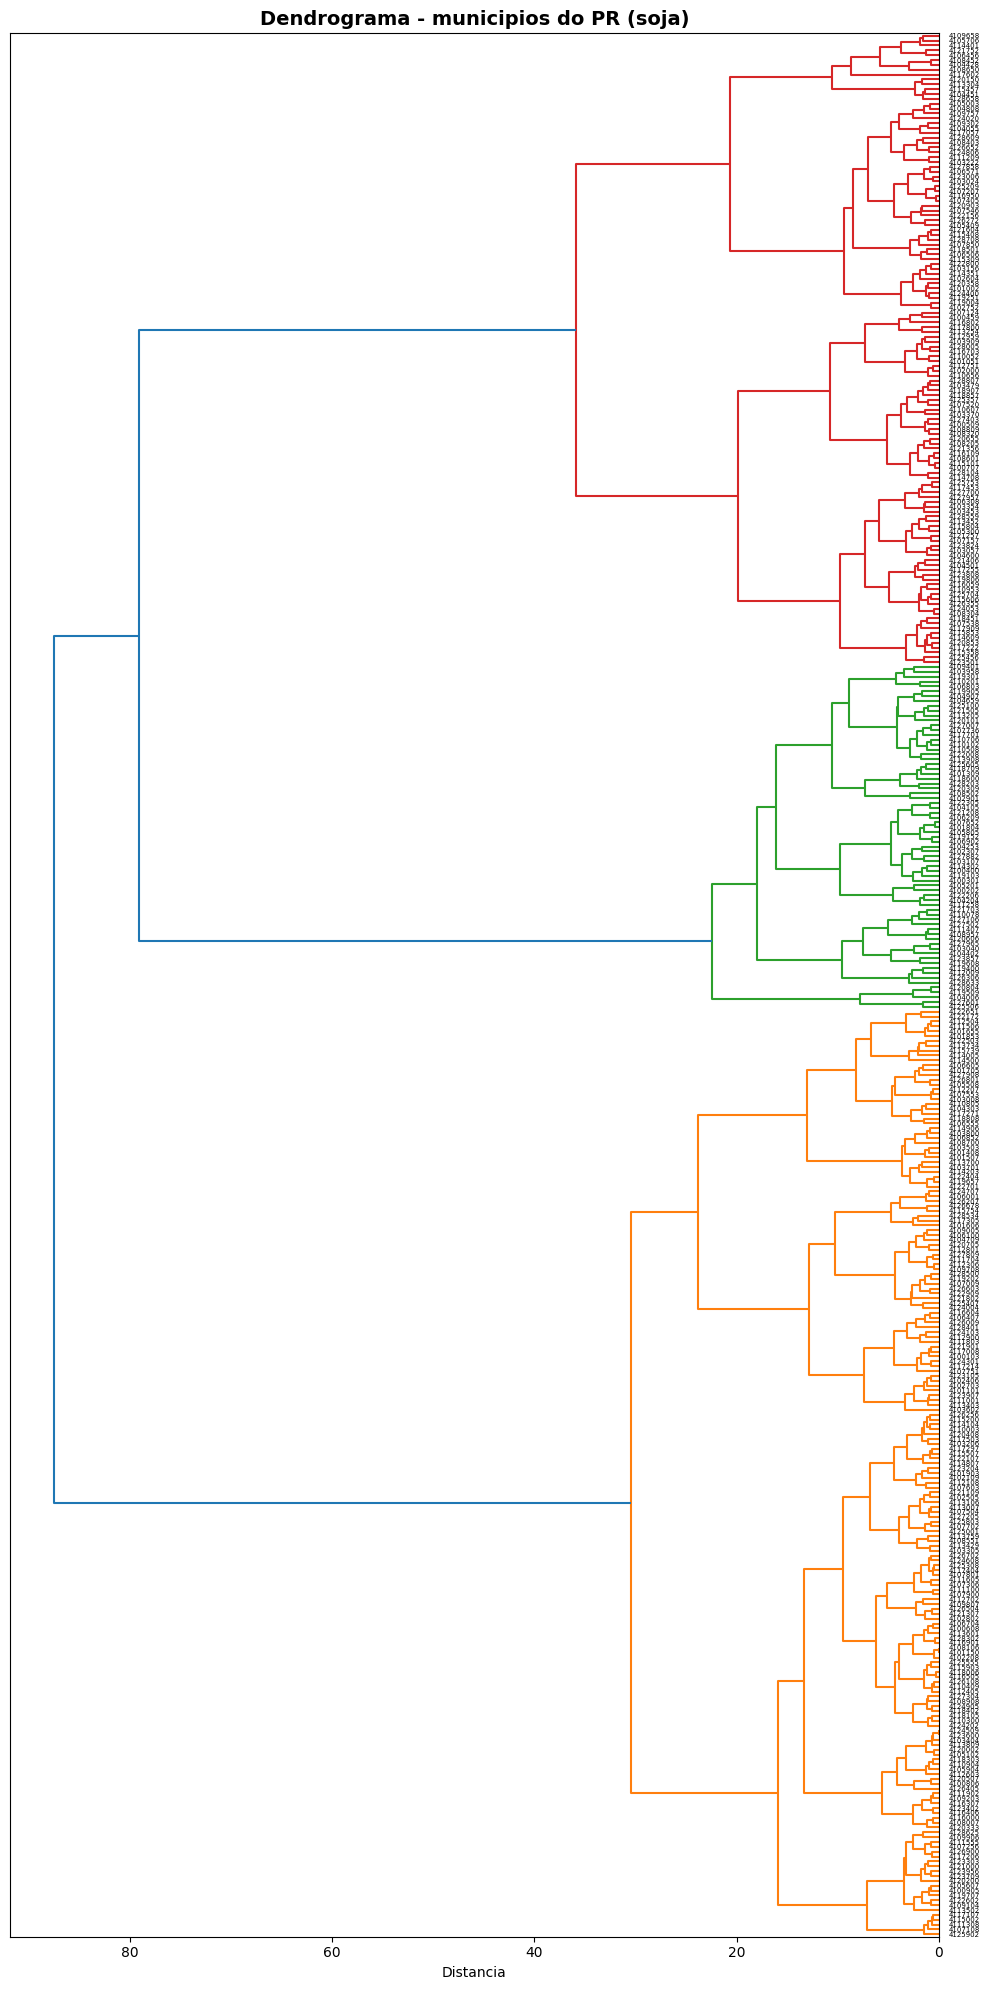

In [4]:
plt.figure(figsize=(10, 20))
dendrogram(
    linkage_matrix,
    labels=df_cluster_clean.index.values,
    orientation='left',
    leaf_font_size=5,
)
plt.title(f'Dendrograma - municipios do PR (soja)', fontsize=14, fontweight='bold')
plt.xlabel('Distancia')
plt.tight_layout()
plt.show()


## Gravar `cluster_id` de volta em cada `point_id_<cod>.nc`


In [5]:
cluster_by_id = df_cluster_clean['Cluster'].to_dict()

n_ok, n_pulado = 0, 0
for arquivo in tqdm(arquivos_nc, desc="Gravando cluster_id"):
    ponto_id = os.path.basename(arquivo).replace('point_id_', '').replace('.nc', '')

    if ponto_id not in cluster_by_id:
        n_pulado += 1
        continue

    with xr.open_dataset(arquivo) as ds:
        ds_loaded = ds.load()

    ds_loaded.attrs['cluster_id'] = float(cluster_by_id[ponto_id])

    tmp_path = arquivo + '.tmp'
    ds_loaded.to_netcdf(tmp_path)
    ds_loaded.close()
    os.replace(tmp_path, arquivo)
    n_ok += 1

print(f"cluster_id gravado em {n_ok} arquivos ({n_pulado} pulados por falta de dados climaticos validos).")


Gravando cluster_id: 100%|██████████| 392/392 [07:03<00:00,  1.08s/it]

cluster_id gravado em 392 arquivos (0 pulados por falta de dados climaticos validos).
